# Lactation-Curve-Shape Clusters × Heat / Udder Health

**Where this sits.** `Clustering_FeaturePairs.ipynb` and `Clustering_ParityStratified.ipynb` showed that the raw production traits (`milk_kg`, `DIM`, `parity`, `AFC`) do **not** form discrete groups — they are a continuum, and the only "clean" pairs were a `parity`-discreteness artifact. So clustering point-data is a dead end.

**The structure that *does* exist** is in the **shape of each lactation curve** over time. This notebook:

1. fits **Wood's** lactation curve to every lactation and clusters the *interpretable* curve features (peak yield, days-to-peak, persistency, 305-d yield) — these are genuine, nameable curve *types* (no PCA);
2. then **links those curve types to heat exposure and udder health (SCS)** — i.e. asks whether a given curve-shape type suffers more heat-driven SCS elevation in summer.

This connects the clustering to the thesis's one robust finding (heat → SCS) instead of leaving it as a standalone exercise.

Read-only on the original CSVs and `farm_weather_indices/`; no existing file is modified.

In [1]:
import os, glob
N_JOBS = max(1, (os.cpu_count() or 2) - 1)
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(_v, str(min(N_JOBS, 8)))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from joblib import Parallel, delayed
import statsmodels.formula.api as smf

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
print(f'Using up to {N_JOBS} cores')

Using up to 7 cores


## Part A — Fit Wood's curve and cluster the curve features

Wood's function $y(t)=a\,t^{b}e^{-ct}$ summarises each lactation by its shape. From the fit we derive **interpretable** features and cluster on those (not the raw `a,b,c`, which are skewed/correlated).

In [2]:
# ---- Load (READ ONLY) and define one lactation = one animal x parity ----
PATH = '../../Thesis_Data/Final_Data/After_Processing.csv'
df = pd.read_csv(PATH, usecols=['Farm_Code', 'Animal_ID', 'parity', 'DIM', 'milk_kg'])
df = df.dropna(subset=['DIM', 'milk_kg'])
df = df[(df['milk_kg'] > 0) & (df['DIM'].between(1, 365))]
df['lact_id'] = df['Animal_ID'].astype(str) + '_p' + df['parity'].astype(int).astype(str)
df = df.sort_values(['lact_id', 'DIM'])
print(f'{len(df):,} records | {df.lact_id.nunique():,} lactations | {df.Animal_ID.nunique():,} animals')

1,646,809 records | 247,247 lactations | 91,221 animals


In [3]:
def wood(t, a, b, c):
    return a * np.power(t, b) * np.exp(-c * t)

def fit_wood(d, m):
    """Fit Wood's curve to one lactation -> interpretable features, or None if unusable."""
    if len(d) < 4 or d.min() > 60 or d.max() < 200:
        return None
    try:
        A = np.column_stack([np.ones_like(d), np.log(d), -d])      # log-linear init
        coef, *_ = np.linalg.lstsq(A, np.log(m), rcond=None)
        p0 = [np.exp(coef[0]), max(coef[1], 1e-3), max(coef[2], 1e-4)]
        p, _ = curve_fit(wood, d, m, p0=p0, maxfev=5000,
                         bounds=([1e-6, 0, 1e-5], [np.inf, 5, 1]))
        a, b, c = p
        pred = wood(d, *p)
        ss_res = np.sum((m - pred) ** 2); ss_tot = np.sum((m - m.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        if r2 < 0.3:
            return None
        peak_dim = b / c
        peak_yield = wood(peak_dim, a, b, c)
        persistency = -(b + 1) * np.log(c)
        tt = np.arange(5, 306)
        yield_305 = np.trapz(wood(tt, a, b, c), tt)
        if not (0 < peak_dim < 365 and 0 < peak_yield < 100):
            return None
        return (a, b, c, peak_dim, peak_yield, persistency, yield_305, r2)
    except Exception:
        return None

groups = [(lid, g['DIM'].values, g['milk_kg'].values) for lid, g in df.groupby('lact_id')]
print(f'Fitting Wood curves to {len(groups):,} lactations...')
res = Parallel(n_jobs=N_JOBS, batch_size=512)(delayed(fit_wood)(d, m) for _, d, m in groups)
cols = ['a', 'b', 'c', 'peak_DIM', 'peak_yield', 'persistency', 'yield_305', 'r2']
rows = [(groups[i][0],) + r for i, r in enumerate(res) if r is not None]
feat = pd.DataFrame(rows, columns=['lact_id'] + cols)
print(f'{len(feat):,} usable fits ({len(feat)/len(groups):.0%}). Median R2 = {feat.r2.median():.2f}')
feat[['peak_DIM', 'peak_yield', 'persistency', 'yield_305']].describe().round(2)

Fitting Wood curves to 247,247 lactations...


/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_32911/1122109765.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_32911/1122109765.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_32911/1122109765.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_32911/1122109765.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_32911/1122109765.py:24: DeprecationWarning: `trapz` is deprecated

152,898 usable fits (62%). Median R2 = 0.84


,peak_DIM,peak_yield,persistency,yield_305
count,"152,898.000","152,898.000","152,898.000","152,898.000"
mean,40.700,13.470,6.660,"2,725.140"
std,29.000,3.260,1.000,628.010
min,0.000,2.920,2.750,394.330
25%,17.910,11.150,6.030,"2,284.080"
50%,42.660,13.200,6.510,"2,681.220"
75%,59.390,15.510,7.060,"3,119.260"
max,364.760,62.860,19.340,"8,894.460"


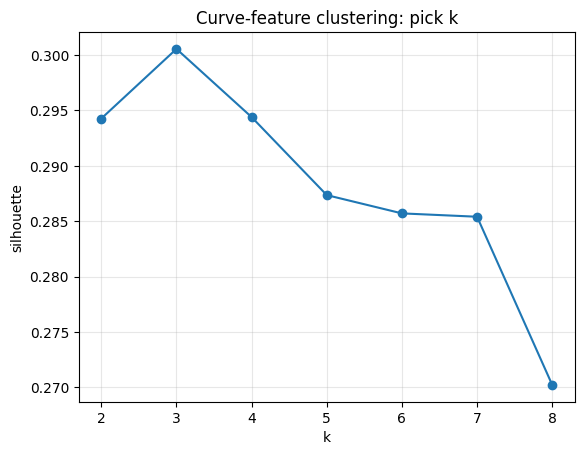

Best k by silhouette = 3


In [4]:
# Cluster on the interpretable curve features (no PCA).
CLUSTER_FEATS = ['peak_DIM', 'peak_yield', 'persistency', 'yield_305']
Xw = StandardScaler().fit_transform(feat[CLUSTER_FEATS].values)

samp = np.random.choice(len(Xw), min(20000, len(Xw)), replace=False)
ks = range(2, 9)
sils = [silhouette_score(Xw[samp], KMeans(k, random_state=RANDOM_STATE, n_init=10).fit_predict(Xw[samp])) for k in ks]
plt.plot(list(ks), sils, 'o-'); plt.xlabel('k'); plt.ylabel('silhouette')
plt.title('Curve-feature clustering: pick k'); plt.grid(alpha=.3); plt.show()
K_FEAT = list(ks)[int(np.argmax(sils))]
print(f'Best k by silhouette = {K_FEAT}')

,peak_DIM,peak_yield,persistency,yield_305,r2,n
cluster,,,,,,
0,23.140,12.000,6.110,"2,354.130",0.780,60103
1,72.670,11.640,7.750,"2,492.090",0.760,43120
2,34.200,16.860,6.380,"3,376.340",0.830,49675


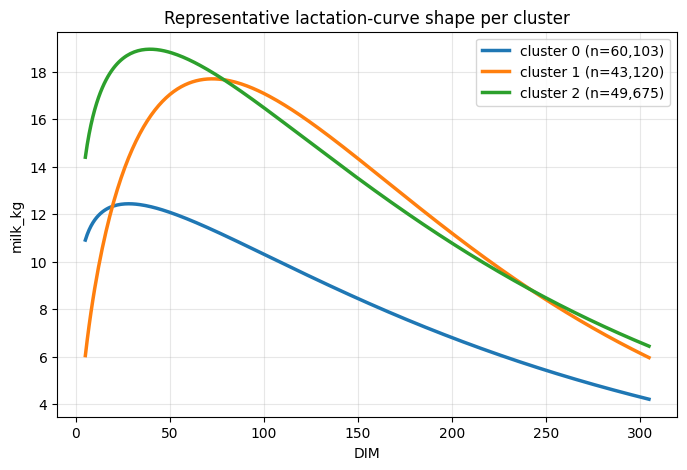

In [5]:
feat['cluster'] = KMeans(K_FEAT, random_state=RANDOM_STATE, n_init=10).fit_predict(Xw)

# Profile each cluster and give it a readable name from peak_yield + persistency.
profile = feat.groupby('cluster')[CLUSTER_FEATS + ['r2']].mean()
profile['n'] = feat['cluster'].value_counts().sort_index()
display(profile.round(2))

# Representative Wood curve per cluster (cluster-mean a,b,c).
means = feat.groupby('cluster')[['a', 'b', 'c']].mean()
tt = np.arange(5, 306)
fig, ax = plt.subplots(figsize=(8, 5))
for cl in range(K_FEAT):
    a, b, cc = means.loc[cl]
    ax.plot(tt, wood(tt, a, b, cc), lw=2.5, label=f'cluster {cl} (n={int(profile.loc[cl, "n"]):,})')
ax.set(title='Representative lactation-curve shape per cluster', xlabel='DIM', ylabel='milk_kg')
ax.legend(); ax.grid(alpha=.3); plt.show()

## Part B — Link curve types to heat exposure and udder health (SCS)

Now merge each test-day record with the **daily-max THI** of its farm/date (from `farm_weather_indices/`), carry **SCS**, and remove the season confound by working with the **THI anomaly** (heat above the farm-month normal). Each record inherits its lactation's **curve cluster**, so we can compare heat → SCS *across curve types*.

In [6]:
# Reload with the fields needed for the heat/SCS analysis (READ ONLY).
_cols = ['Animal_ID', 'Farm_Code', 'parity', 'DIM', 'milk_kg', 'dtt', 'SCS']
H = pd.read_csv(PATH, usecols=_cols)
H['SCS'] = pd.to_numeric(H['SCS'], errors='coerce')
H = H.dropna(subset=['DIM', 'milk_kg', 'dtt'])
H = H[(H['milk_kg'] > 0) & (H['DIM'].between(1, 365))]
H['lact_id'] = H['Animal_ID'].astype(str) + '_p' + H['parity'].astype(int).astype(str)
H['farm'] = H['Farm_Code'].astype(str).str.replace(r'\.0$', '', regex=True)
H['date'] = pd.to_datetime(H['dtt'], errors='coerce')
H['month'] = H['date'].dt.month
H['dstr'] = H['date'].dt.strftime('%Y-%m-%d')

# Merge daily-max THI per farm/date.
parts = []
for f in glob.glob('../../Thesis_Data/farm_weather_indices/farm_*_with_indices.csv'):
    c = os.path.basename(f).split('_')[1].replace('.0', '')
    w = pd.read_csv(f, usecols=['date', 'THI_2_max']).dropna().rename(columns={'date': 'dstr'})
    w['farm'] = c
    parts.append(w)
Wx = pd.concat(parts, ignore_index=True)
H = H.merge(Wx, on=['farm', 'dstr'], how='left').dropna(subset=['THI_2_max'])

# Season removal -> THI anomaly above the farm-month normal.
H['thi_anom'] = H['THI_2_max'] - H.groupby(['farm', 'month'])['THI_2_max'].transform('mean')

# Attach the curve-shape cluster to every record via its lactation.
H = H.merge(feat[['lact_id', 'cluster']], on='lact_id', how='inner')
print(f'H: {len(H):,} records with THI + curve cluster | THI matched {H.THI_2_max.notna().mean():.0%}')
print('records per curve cluster:'); print(H['cluster'].value_counts().sort_index())

H: 1,159,537 records with THI + curve cluster | THI matched 100%
records per curve cluster:
cluster
0    451151
1    325070
2    383316
Name: count, dtype: int64


Summer SCS by curve cluster (higher = worse udder health):


day,hot-anomaly,normal,hot_minus_normal
cluster,,,
0,3.236,3.090,0.146
1,3.060,2.950,0.110
2,3.032,2.981,0.051


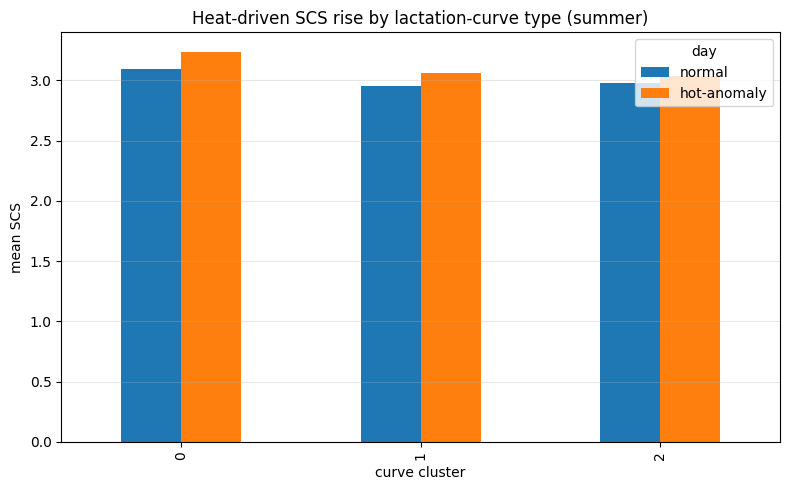

In [7]:
# Summer udder health: mean SCS on hot-for-the-season days vs normal days, BY curve cluster.
summer = H[H['month'].isin([6, 7, 8, 9])].copy()
summer['day'] = np.where(summer['thi_anom'] > 2, 'hot-anomaly', 'normal')
tab = summer.pivot_table('SCS', 'cluster', 'day', observed=True)
tab['hot_minus_normal'] = tab['hot-anomaly'] - tab['normal']
print('Summer SCS by curve cluster (higher = worse udder health):')
display(tab.round(3))

ax = tab[['normal', 'hot-anomaly']].plot(kind='bar', figsize=(8, 5))
ax.set(title='Heat-driven SCS rise by lactation-curve type (summer)',
       xlabel='curve cluster', ylabel='mean SCS')
ax.grid(alpha=.3, axis='y'); plt.tight_layout(); plt.show()

In [8]:
# Rigorous test: does the within-animal heat -> SCS slope differ by curve cluster?
# Within-animal demean = animal fixed effects; farm-clustered SE; summer only.
def fe_slope(frame, yvar='SCS', xvar='thi_anom', cluster='farm'):
    f = frame.dropna(subset=[yvar, xvar]).copy()
    f['y'] = f[yvar] - f.groupby('Animal_ID')[yvar].transform('mean')
    f['x'] = f[xvar] - f.groupby('Animal_ID')[xvar].transform('mean')
    m = smf.ols('y ~ x', data=f).fit(cov_type='cluster', cov_kwds={'groups': f[cluster]})
    return m.params['x'], m.pvalues['x'], len(f)

print('Within-animal heat -> SCS slope per curve cluster (summer):')
rows = []
for cl in sorted(summer['cluster'].unique()):
    b, p, n = fe_slope(summer[summer['cluster'] == cl])
    rows.append({'cluster': cl, 'SCS_per_+1_THI_anom': round(b, 4),
                 'SCS_per_+10_THI': round(b * 10, 3), 'p_value': p, 'n': n})
    print(f"  cluster {cl}: {b:+.4f} per +1 THI-anom  (+10 THI = {b*10:+.3f} SCS)  p={p:.1e}  n={n:,}")
display(pd.DataFrame(rows))

Within-animal heat -> SCS slope per curve cluster (summer):
  cluster 0: +0.0074 per +1 THI-anom  (+10 THI = +0.074 SCS)  p=6.0e-04  n=149,718
  cluster 1: +0.0088 per +1 THI-anom  (+10 THI = +0.088 SCS)  p=3.1e-04  n=107,288
  cluster 2: +0.0094 per +1 THI-anom  (+10 THI = +0.094 SCS)  p=1.3e-03  n=132,136


,cluster,SCS_per_+1_THI_anom,SCS_per_+10_THI,p_value,n
0,0,0.007,0.074,0.001,149718
1,1,0.009,0.088,0.000,107288
2,2,0.009,0.094,0.001,132136


## How to read this

- **Part A** gives genuine, interpretable lactation-curve *types* (e.g. high-peak/low-persistency vs flat/persistent). Unlike the point-trait clustering, these are real structure and are described in biological units — and with no PCA.
- **Part B** is the thesis payoff: if one curve type shows a clearly **steeper heat → SCS slope** (larger, significant `SCS_per_+10_THI`), that type is the heat-vulnerable udder-health group, and the curve features become a screening tool. If the slopes are similar across clusters, the honest conclusion is that heat raises SCS **across all curve types** roughly equally — still a clean, reportable result.
- Keep the framing consistent with `Clustering_TimeSeries.ipynb`: report **milk as a null** (heat barely moves yield) and **SCS as the real effect**; here we additionally test whether curve shape modifies that SCS effect.